# Trace recursive_opt vs stock EvoX (EXP22–EXP27): performance, cheating and exploration

Both engines use the same LLM (`z-ai/glm-5.3-flash` via Novita, temperature 0.7) and 100 solution calls per run.
Tasks are SkyDiscover **Signal Processing** (higher is better; start 0.499) and **PRISM** GPU placement.
**Legitimate** means *causal* on Signal (output never uses future samples; the task asks for real-time
filtering) and *all 50 cases solved* on PRISM (the stock metric skips failed cases). The **cue** is the
`causal_fraction` audit metric, which Trace's prompts printed and EvoX's never did.

In [1]:
import json, math, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Markdown
R = Path('../..')  # experiments/recursive_opt
load = lambda p: json.loads((R / p).read_text())
curves = load('EXP27/results/learning_curves.json')['runs']        # every Signal run: (iteration, valid score, causal) per candidate
yield_ = load('EXP27/results/instruction_yield.json')              # SciPy introduced per instruction, before each run's first SciPy
timeline = load('EXP27/results/strategy_timeline.json')['summary']   # instruction mix per 25-iteration window
partD = load('EXP27/results/partD_20261006T195738/analysis.json')['summary']
prism_rescore = load('_analysis/assessment_20260930/prism_rescoring.json')['results']
exp24 = load('EXP24/results/clean_20260930T115256/analysis.json')
OPT, INIT = exp24['optimum'], 0.499
ENGINE = lambda arm: 'EvoX' if arm == 'stock EvoX' else 'Trace'
GROUP = lambda arm: 'EvoX' if arm == 'stock EvoX' else ('Trace, cue hidden' if 'cue_off' in arm else 'Trace, cue shown')
GROUPS = ('EvoX', 'Trace, cue shown', 'Trace, cue hidden')
COL = {'EvoX': '#d95f02', 'Trace': '#1b6ca8', 'Trace, cue shown': '#1b6ca8', 'Trace, cue hidden': '#66a61e'}

def best_so_far(points, causal_only, horizon=100):
    by_it = {}
    for it, v, c in points:
        if c or not causal_only:
            by_it[it] = max(by_it.get(it, 0), v)
    best, out = INIT, np.empty(horizon)
    for k in range(1, horizon + 1):   # EXP26 runs end at iterations 43-70 (key limit): their best is carried forward
        best = max(best, by_it.get(k, 0)); out[k - 1] = best
    return out

MAX_CAUSAL = max(v for r in curves.values() for _, v, c in r['points'] if c)
STRONG = round(MAX_CAUSAL + 0.05, 3)  # look-ahead threshold: beats every causal score ever observed by 0.05
discovery = lambda points: next((it for it, v, c in sorted(points) if not c and v >= STRONG), None)
print(f'{len(curves)} Signal runs; best causal score in any run = {MAX_CAUSAL}; look-ahead threshold = {STRONG}')

32 Signal runs; best causal score in any run = 0.5651; look-ahead threshold = 0.615


**Table 1 — Signal Processing, every recorded run** (medians over runs). *Raw* = the benchmark's own score; *causal* = real-time candidates only; *look-ahead* = a non-causal candidate at or above the threshold printed above.

In [2]:
rows = []
for key, r in curves.items():
    p = r['points']
    rows.append({'Experiment': key.split('/')[0], 'Arm': r['arm'].replace('EXP25 ', '').replace('EXP26 ', '').replace('EXP27 trace ', 'trace '),
                 'Engine': ENGINE(r['arm']), 'Group': GROUP(r['arm']), 'Iterations': max(x[0] for x in p),
                 'Raw best': max(v for _, v, _ in p), 'Causal best': max([INIT] + [v for _, v, c in p if c]),
                 'Look-ahead': discovery(p) is not None, 'Found at': discovery(p)})
runs = pd.DataFrame(rows)
order = ['stock EvoX', 'trace_exp23', 'trace_exp24', 'native', 'native_pkg', 'native_stocklabels', 'trace cue_on', 'trace cue_off']
t1 = (runs.groupby(['Engine', 'Experiment', 'Arm'], sort=False)
          .agg(Runs=('Raw best', 'size'), Iterations=('Iterations', lambda s: f'{s.min()}–{s.max()}'),
               Raw_best=('Raw best', 'median'), Causal_best=('Causal best', 'median'),
               Look_ahead_runs=('Look-ahead', lambda s: f'{s.sum()}/{len(s)}'),
               Found_at_iteration=('Found at', lambda s: ', '.join(str(int(x)) for x in sorted(s.dropna())) or '–'))
          .reset_index())
t1['Arm'] = pd.Categorical(t1['Arm'], order, ordered=True)
t1 = t1.sort_values(['Arm', 'Experiment']).rename(columns=lambda c: c.replace('_', ' '))
display(t1.style.hide(axis='index').format({'Raw best': '{:.3f}', 'Causal best': '{:.3f}'})
        .background_gradient(subset=['Raw best'], cmap='Oranges', vmin=0.5, vmax=0.75)
        .set_table_styles([{'selector': 'td, th', 'props': 'font-size: 9pt; padding: 1px 6px'}]))

Engine,Experiment,Arm,Runs,Iterations,Raw best,Causal best,Look ahead runs,Found at iteration
EvoX,EXP25,stock EvoX,3,100–100,0.713,0.537,3/3,"17, 23, 29"
EvoX,EXP26,stock EvoX,3,64–69,0.709,0.549,2/3,"5, 23"
Trace,EXP25,trace_exp23,3,97–100,0.555,0.531,0/3,–
Trace,EXP25,trace_exp24,3,100–100,0.586,0.532,0/3,–
Trace,EXP26,native,3,43–56,0.652,0.525,2/3,"13, 21"
Trace,EXP26,native_pkg,3,42–59,0.554,0.530,0/3,–
Trace,EXP26,native_stocklabels,3,44–62,0.576,0.558,1/3,62
Trace,EXP27,trace cue_on,3,100–100,0.548,0.525,1/3,14
Trace,EXP27,trace cue_off,8,99–100,0.637,0.539,6/8,"3, 36, 42, 43, 80, 92"


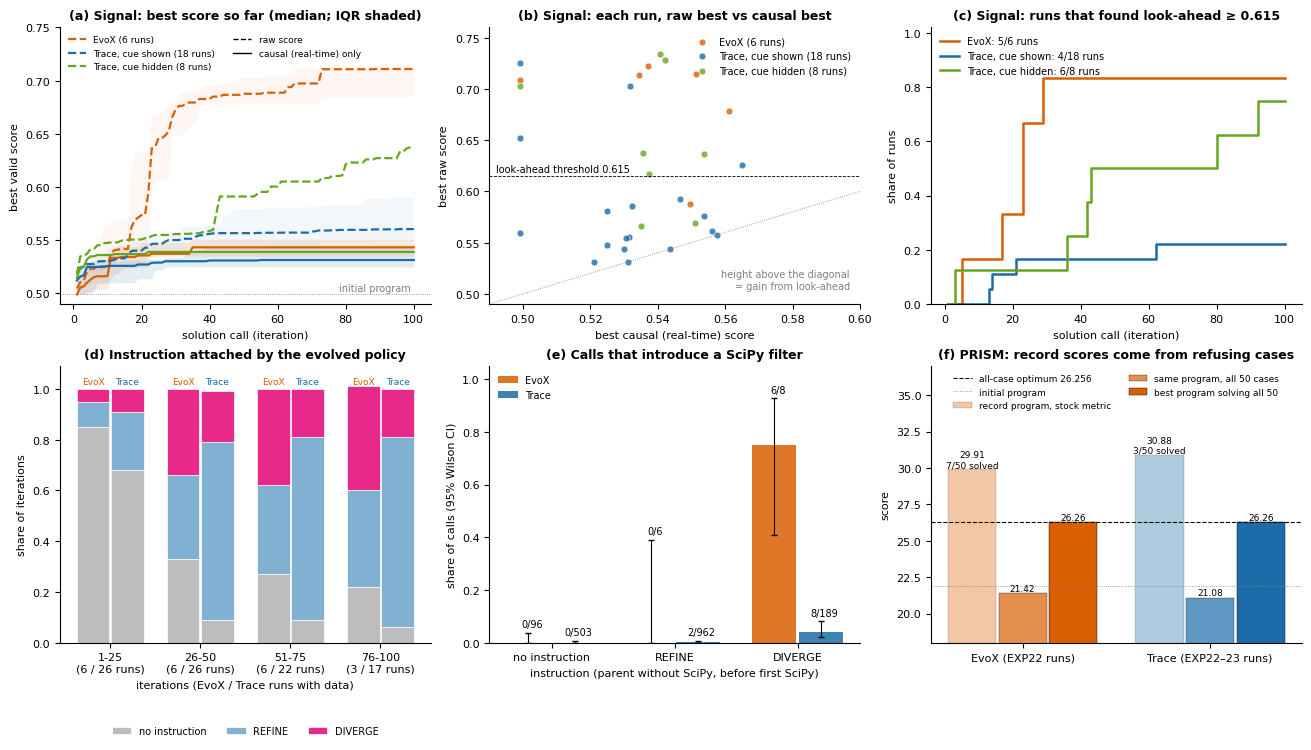

In [3]:
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9, 'axes.titleweight': 'bold', 'axes.spines.top': False, 'axes.spines.right': False})
fig, ax = plt.subplots(2, 3, figsize=(13, 7.4), constrained_layout=True)
it = np.arange(1, 101)

# (a) learning curves
a = ax[0, 0]
for g in GROUPS:
    keys = [k for k, r in curves.items() if GROUP(r['arm']) == g]
    for causal, ls in ((False, '--'), (True, '-')):
        m = np.array([best_so_far(curves[k]['points'], causal) for k in keys])
        a.plot(it, np.median(m, 0), ls, color=COL[g], lw=1.6, label=f'{g} ({len(keys)} runs)' if not causal else None)
        if g != 'Trace, cue hidden':
            a.fill_between(it, np.percentile(m, 25, 0), np.percentile(m, 75, 0), color=COL[g], alpha=0.12 if causal else 0.05, lw=0)
a.plot([], [], 'k--', lw=1, label='raw score'); a.plot([], [], 'k-', lw=1, label='causal (real-time) only')
a.axhline(INIT, color='grey', lw=0.6, ls=':'); a.text(99, INIT + 0.003, 'initial program', ha='right', color='grey', fontsize=7)
a.set(title='(a) Signal: best score so far (median; IQR shaded)', xlabel='solution call (iteration)', ylabel='best valid score', ylim=(0.49, 0.75))
a.legend(fontsize=6.5, loc='upper left', frameon=False, ncol=2)

# (b) per-run raw vs causal
b = ax[0, 1]
for g in GROUPS:
    d = runs[runs.Group == g]
    b.scatter(d['Causal best'], d['Raw best'], s=24, color=COL[g], alpha=0.8, edgecolor='white', lw=0.5, label=f'{g} ({len(d)} runs)')
b.plot([0.49, 0.76], [0.49, 0.76], color='grey', lw=0.6, ls=':')
b.axhline(STRONG, color='black', lw=0.6, ls='--'); b.text(0.492, STRONG + 0.004, f'look-ahead threshold {STRONG}', fontsize=7)
b.set(title='(b) Signal: each run, raw best vs causal best', xlabel='best causal (real-time) score', ylabel='best raw score',
      xlim=(0.49, 0.6), ylim=(0.49, 0.76))
b.text(0.597, 0.505, 'height above the diagonal\n= gain from look-ahead', ha='right', fontsize=7, color='grey')
b.legend(fontsize=7, loc='upper right', frameon=False)

# (c) cumulative discovery of look-ahead
c = ax[0, 2]
for g in GROUPS:
    d = runs[runs.Group == g]; found = d['Found at'].dropna()
    c.step(it, [(found <= k).sum() / len(d) for k in it], where='post', color=COL[g], lw=1.8, label=f'{g}: {len(found)}/{len(d)} runs')
c.set(title=f'(c) Signal: runs that found look-ahead ≥ {STRONG}', xlabel='solution call (iteration)', ylabel='share of runs', ylim=(0, 1.02))
c.legend(fontsize=7, loc='upper left', frameon=False)

# (d) instruction mix over time
d_ = ax[1, 0]; w = np.arange(4); width = 0.38
kinds = [('unlabelled', 'no instruction', '#bdbdbd'), ('refine', 'REFINE', '#80b1d3'), ('diverge', 'DIVERGE', '#e7298a')]
for j, eng in enumerate(('stock', 'trace')):
    bottom = np.zeros(4)
    for kind, lab, col in kinds:
        v = np.array([row[kind] for row in timeline[eng]])
        d_.bar(w + (j - 0.5) * width, v, width * 0.95, bottom=bottom, color=col, edgecolor='white', lw=0.5, label=lab if j == 0 else None)
        bottom += v
    name = 'EvoX' if eng == 'stock' else 'Trace'
    for x in w:
        d_.text(x + (j - 0.5) * width, 1.02, name, ha='center', fontsize=6.5, color=COL[name])
d_.set_xticks(w, [f"{r['iters']}\n({timeline['stock'][i]['runs']} / {timeline['trace'][i]['runs']} runs)" for i, r in enumerate(timeline['stock'])])
d_.set_ylim(0, 1.09)
d_.set(title='(d) Instruction attached by the evolved policy', xlabel='iterations (EvoX / Trace runs with data)', ylabel='share of iterations')
d_.legend(fontsize=7, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.27), frameon=False)

# (e) yield per instruction, Wilson 95% CI
def wilson(k, n, z=1.96):
    p = k / n; den = 1 + z * z / n; mid = (p + z * z / (2 * n)) / den; half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, p - (mid - half), (mid + half) - p
e = ax[1, 1]; labs = ['none', 'refine', 'diverge']
for j, eng in enumerate(('stock', 'trace')):
    vals = [wilson(yield_[eng][l]['scipy'], yield_[eng][l]['calls']) for l in labs]
    x = np.arange(3) + (j - 0.5) * 0.38; name = 'EvoX' if eng == 'stock' else 'Trace'
    e.bar(x, [v[0] for v in vals], 0.36, color=COL[name], alpha=0.85, label=name)
    e.errorbar(x, [v[0] for v in vals], yerr=[[v[1] for v in vals], [v[2] for v in vals]], fmt='none', ecolor='black', lw=0.8, capsize=2)
    for xi, l, v in zip(x, labs, vals):
        e.text(xi + 0.03, v[0] + v[2] + 0.02, f"{yield_[eng][l]['scipy']}/{yield_[eng][l]['calls']}", ha='center', fontsize=7)
e.set_xticks(range(3), ['no instruction', 'REFINE', 'DIVERGE']); e.set_ylim(0, 1.05)
e.set(title='(e) Calls that introduce a SciPy filter', ylabel='share of calls (95% Wilson CI)', xlabel='instruction (parent without SciPy, before first SciPy)')
e.legend(fontsize=7, frameon=False, loc='upper left')

# (f) PRISM: record programs vs all 50 cases vs best fully solved
f = ax[1, 2]
sel = {'EvoX': prism_rescore['EXP22_evox_selected']['metrics'], 'Trace': prism_rescore['EXP23_trace_selected']['metrics']}
def best_fully_solved(patterns):
    best = 0.0
    for pat in patterns:
        for h in glob.glob(str(R / pat)):
            for line in open(h):
                m = (json.loads(line).get('candidate') or {}).get('metrics') or {}
                if isinstance(m.get('combined_score'), (int, float)) and (m.get('success_rate') or 0) >= 1:
                    best = max(best, m['combined_score'])
    return best
full = {'EvoX': best_fully_solved(['EXP22/runs/strict_prism_SD-EVOX_*/candidate_history.jsonl']),
        'Trace': best_fully_solved(['EXP22/runs/strict_prism_TRACE-*/candidate_history.jsonl',
                                    'EXP22/artifacts/parallel_trace_*/v9_runtime/runs/strict_prism_TRACE-*/candidate_history.jsonl',
                                    'EXP23/results/prism100/*/*/candidate_history.jsonl'])}
x, wd = np.arange(2), 0.27
for off, vals, alpha, lab in ((-wd, {k: sel[k]['combined_score'] for k in sel}, 0.35, 'record program, stock metric'),
                             (0, {k: sel[k]['valid_score'] for k in sel}, 0.7, 'same program, all 50 cases'),
                             (wd, full, 1.0, 'best program solving all 50')):
    f.bar(x + off, [vals[k] for k in sel], wd * 0.95, color=[COL[k] for k in sel], alpha=alpha, label=lab, edgecolor='black', lw=0.3)
    for xi, k in zip(x, sel):
        extra = f"\n{round(sel[k]['success_rate'] * 50)}/50 solved" if off < 0 else ''
        f.text(xi + off, vals[k] + 0.15, f'{vals[k]:.2f}{extra}', ha='center', fontsize=6.5)
f.axhline(OPT, color='black', lw=0.8, ls='--', label=f'all-case optimum {OPT:.3f}')
f.axhline(prism_rescore['initial']['metrics']['valid_score'], color='grey', lw=0.6, ls=':', label='initial program')
f.set_xticks(x, ['EvoX (EXP22 runs)', 'Trace (EXP22–23 runs)']); f.set_ylim(18, 37)
f.set(title='(f) PRISM: record scores come from refusing cases', ylabel='score')
f.legend(fontsize=6.5, frameon=False, loc='upper center', ncol=2)
plt.show()

**Table 2 — PRISM after the EXP24 operator and evaluator fix** (3 seeds per arm, 100 calls each; *fixed* = no meta-optimization).

In [4]:
p = pd.DataFrame(exp24['runs']); p['Arm'] = p['run'].str.rsplit('_s', n=1).str[0]
t2 = p.groupby('Arm', sort=False).agg(Runs=('run', 'size'),
        Reached_optimum=('best_valid', lambda s: f'{(s >= OPT - 1e-6).sum()}/{len(s)}'),
        Calls_to_optimum=('calls_to_optimum', lambda s: f"{int(s.median())} ({', '.join(map(str, s))})"),
        Wasted_attempts=('wasted_attempts', 'mean'), Policies_deployed=('policy_deployments', 'mean'), Cost_USD=('cost_usd', 'sum')).reset_index()
t2['Arm'] = t2['Arm'].replace({'fixed': 'fixed policy', 'llm_rewrite': 'EvoX-style meta (llm_rewrite)', 'trace': 'Trace meta (OptoPrime)'})
display(t2.rename(columns=lambda c: c.replace('_', ' ')).style.hide(axis='index')
        .format({'Wasted attempts': '{:.1f}', 'Policies deployed': '{:.1f}', 'Cost USD': '${:.2f}'})
        .set_table_styles([{'selector': 'td, th', 'props': 'font-size: 9pt; padding: 1px 6px'}]))

def fisher(k1, n1, k2, n2):  # one-sided exact test that group 1's rate is higher
    return sum(math.comb(n1, x) * math.comb(n2, k1 + k2 - x) for x in range(k1, min(n1, k1 + k2) + 1)) / math.comb(n1 + n2, k1 + k2)
G = {g: runs[runs.Group == g] for g in GROUPS}
n = {g: (int(G[g]['Look-ahead'].sum()), len(G[g])) for g in GROUPS}
p_evox, p_cue = fisher(*n['EvoX'], *n['Trace, cue shown']), fisher(*n['Trace, cue hidden'], *n['Trace, cue shown'])
same = runs[runs.Arm.isin(['native', 'trace cue_on'])]  # same engine configuration as the cue-hidden runs, cue shown
n_same = (int(same['Look-ahead'].sum()), len(same)); p_same = fisher(*n['Trace, cue hidden'], *n_same)
cheat = {g: G[g][G[g]['Look-ahead']]['Raw best'].median() for g in GROUPS}
first = {g: sorted(G[g]['Found at'].dropna().astype(int)) for g in GROUPS}
pct = lambda v: f'{v:.0%}'
display(Markdown(f'''**Findings** (every number computed above).
1. **No legitimate gap.** Median best causal Signal score: EvoX {G['EvoX']['Causal best'].median():.3f}, Trace
   {runs[runs.Engine == 'Trace']['Causal best'].median():.3f} (start {INIT}). On PRISM, the best program solving all 50 cases scores
   {full['EvoX']:.3f} for EvoX and {full['Trace']:.3f} for Trace (optimum {OPT:.3f}). Each engine's PRISM record (EvoX
   {sel['EvoX']['combined_score']:.2f}, Trace {sel['Trace']['combined_score']:.2f}) solves at most
   {round(max(s['success_rate'] for s in sel.values()) * 50)}/50 cases and drops to {sel['EvoX']['valid_score']:.2f} and
   {sel['Trace']['valid_score']:.2f} on all 50 (a, b, f).
2. **EvoX's Signal lead is cheat discovery, not better optimization.** Look-ahead ≥ {STRONG}: EvoX {n['EvoX'][0]}/{n['EvoX'][1]} runs
   (iterations {', '.join(map(str, first['EvoX']))}) vs Trace with the cue shown {n['Trace, cue shown'][0]}/{n['Trace, cue shown'][1]}
   (one-sided Fisher p = {p_evox:.3f}). With the cue hidden, Trace finds look-ahead in {n['Trace, cue hidden'][0]}/{n['Trace, cue hidden'][1]}
   runs (p = {p_cue:.3f} vs all cue-shown runs; p = {p_same:.3f} vs the {n_same[1]} same-configuration runs, {n_same[0]}/{n_same[1]}), but mostly in weaker hand-written forms: median cheating score {cheat['Trace, cue hidden']:.3f} vs EvoX
   {cheat['EvoX']:.3f} (c). Once Trace finds the SciPy form, it climbs it as far: +{partD['cue_off']['median_climb_after']:.3f} vs EvoX
   +{partD['stock']['median_climb_after']:.3f} (Part D).
3. **What Trace lacks is exploration.** SciPy filters come almost only from DIVERGE calls: EvoX
   {yield_['stock']['diverge']['scipy']}/{yield_['stock']['diverge']['calls']}, Trace {yield_['trace']['diverge']['scipy']}/{yield_['trace']['diverge']['calls']} (e).
   After iteration 25, EvoX's evolved policies attach DIVERGE in {pct(timeline['stock'][1]['diverge'])}–{pct(timeline['stock'][3]['diverge'])}
   of iterations. Trace's OptoPrime-written policies lock into REFINE ({pct(timeline['trace'][1]['refine'])}–{pct(timeline['trace'][3]['refine'])})
   and always show 4 elite programs (d). The meta level has never beaten a fixed policy (Table 2).

*Limits:* 3 seeds per arm (EvoX 6, cue hidden 8). The look-ahead threshold is data-derived (best causal score seen + 0.05). The
pre-registered SciPy-only count for cue hidden was {partD['cue_off']['E']}/{partD['cue_off']['runs']}. EXP26 runs stop at iterations 43–70
(key limit; best carried forward). The Signal causal ceiling is unknown. Sources: `EXP24`–`EXP27/results/`, `EXP27/scripts/`.'''))

Arm,Runs,Reached optimum,Calls to optimum,Wasted attempts,Policies deployed,Cost USD
fixed policy,3,3/3,"12 (8, 12, 32)",8.7,0.0,$0.45
EvoX-style meta (llm_rewrite),3,3/3,"12 (12, 5, 33)",23.3,6.7,$0.52
Trace meta (OptoPrime),3,3/3,"22 (45, 22, 8)",15.0,7.0,$0.51


**Findings** (every number computed above).
1. **No legitimate gap.** Median best causal Signal score: EvoX 0.543, Trace
   0.534 (start 0.499). On PRISM, the best program solving all 50 cases scores
   26.256 for EvoX and 26.256 for Trace (optimum 26.256). Each engine's PRISM record (EvoX
   29.91, Trace 30.88) solves at most
   7/50 cases and drops to 21.42 and
   21.08 on all 50 (a, b, f).
2. **EvoX's Signal lead is cheat discovery, not better optimization.** Look-ahead ≥ 0.615: EvoX 5/6 runs
   (iterations 5, 17, 23, 23, 29) vs Trace with the cue shown 4/18
   (one-sided Fisher p = 0.015). With the cue hidden, Trace finds look-ahead in 6/8
   runs (p = 0.017 vs all cue-shown runs; p = 0.343 vs the 6 same-configuration runs, 3/6), but mostly in weaker hand-written forms: median cheating score 0.670 vs EvoX
   0.713 (c). Once Trace finds the SciPy form, it climbs it as far: +0.050 vs EvoX
   +0.045 (Part D).
3. **What Trace lacks is exploration.** SciPy filters come almost only from DIVERGE calls: EvoX
   6/8, Trace 8/189 (e).
   After iteration 25, EvoX's evolved policies attach DIVERGE in 34%–41%
   of iterations. Trace's OptoPrime-written policies lock into REFINE (70%–75%)
   and always show 4 elite programs (d). The meta level has never beaten a fixed policy (Table 2).

*Limits:* 3 seeds per arm (EvoX 6, cue hidden 8). The look-ahead threshold is data-derived (best causal score seen + 0.05). The
pre-registered SciPy-only count for cue hidden was 2/8. EXP26 runs stop at iterations 43–70
(key limit; best carried forward). The Signal causal ceiling is unknown. Sources: `EXP24`–`EXP27/results/`, `EXP27/scripts/`.

---
## Appendix — the two tasks and their loopholes (code excerpts are read from the source files)

In [5]:
import sys, os, io, contextlib, re, importlib.util
SKY = Path('/home/xav/code/evo-compare/repos/skydiscover/benchmarks')   # SkyDiscover checkout used by every run
def excerpt(path, *ranges, title=''):
    lines = Path(path).read_text().splitlines()
    print(f'--- {title} [{Path(path).relative_to(Path(path).parents[2])}]')
    for lo, hi in ranges:
        for i in range(lo, hi + 1):
            print(f'{i:4d}  {lines[i - 1]}')
        print('   ...')
os.environ.setdefault('TRACE_ROOT', str(Path('../../../..').resolve()))
sys.path.insert(0, str(R / 'EXP25/signal')); import whitebox as W
SIG = {'initial': W.INITIAL,
       'best legitimate (Trace, EXP26 native_stocklabels s42)': R / 'EXP26/results/runs_20261006T112918/native_stocklabels_s42/sources/65597d063538c1b69d2dec9b279803f9cb7e9a3e6da395f40898da65029c6bf0.py',
       'cheat (EvoX, EXP25 s43 returned program)': R / 'EXP25/results/runs_20260930T235849/evox_stock_s43/best_program.py'}
sig = {k: W.evaluate(Path(p).read_text())[0] for k, p in SIG.items()}
display(pd.DataFrame({k: {'benchmark score': m['combined_score'], 'causal fraction of signals': m['causal_fraction']} for k, m in sig.items()}).T
        .style.format('{:.3f}').set_table_styles([{'selector': 'td, th', 'props': 'font-size: 9pt; padding: 1px 6px'}]))

,benchmark score,causal fraction of signals
initial,0.499,1.000
"best legitimate (Trace, EXP26 native_stocklabels s42)",0.565,1.000
"cheat (EvoX, EXP25 s43 returned program)",0.723,0.000


### Signal Processing
**Task.** Filter 5 noisy, non-stationary test signals (sinusoids, multi-frequency, chirp, steps, random walk) with a
sliding window of W = 20 samples, *in real time*. **Goal.** Maximize `combined_score` = 0.4·composite (fewer slope
reversals, low lag, low tracking error) + 0.2·smoothness + 0.2·correlation with the clean signal + 0.1·noise
reduction + 0.1·success. **The cheat.** `scipy.signal.filtfilt` runs a filter forwards and then backwards. Its output
at time *t* therefore depends on samples after *t*: zero lag, but impossible in real time. `savgol_filter` and
`medfilt` are centred windows and also read the future. The evaluator never checks this; EXP25's probe does, by
re-running each signal without its last 50 samples (a causal filter's earlier outputs must not change).

In [6]:
excerpt(SIG['initial'], (31, 35), title='initial: trailing moving average')
excerpt(SIG['best legitimate (Trace, EXP26 native_stocklabels s42)'], (59, 64), (66, 76), title='best causal (0.565): EMA + endpoint Savitzky-Golay fit')
excerpt(SIG['cheat (EvoX, EXP25 s43 returned program)'], (7, 7), (26, 34), title='EvoX cheat (0.723): zero-phase filtfilt + centred filters')
from scipy.signal import butter, filtfilt, lfilter
x = np.random.default_rng(0).normal(size=1000); b, a = butter(4, 0.065)
drift = lambda f: np.abs(f(b, a, x)[:950] - f(b, a, x[:950])).max()
print(f'Dropping the last 50 samples changes the earlier outputs (0-949) by up to: lfilter (causal) {drift(lfilter):.2f}, '
      f'filtfilt {drift(filtfilt):.2f} (signal std 1)')

--- initial: trailing moving average [math/signal_processing/initial_program.py]
  31      for i in range(output_length):
  32          window = x[i : i + window_size]
  33  
  34          # Basic moving average filter
  35          y[i] = np.mean(window)
   ...
--- best causal (0.565): EMA + endpoint Savitzky-Golay fit [native_stocklabels_s42/sources/65597d063538c1b69d2dec9b279803f9cb7e9a3e6da395f40898da65029c6bf0.py]
  59      # --- Light causal pre-smoothing (EMA) to reduce noise-induced reversals ---
  60      alpha = 0.32
  61      smoothed = np.empty_like(x)
  62      smoothed[0] = x[0]
  63      for i in range(1, len(x)):
  64          smoothed[i] = alpha * x[i] + (1.0 - alpha) * smoothed[i - 1]
   ...
  66      # --- Precompute causal Savitzky-Golay coefficients (endpoint evaluation) ---
  67      # Fit polynomial of order 3 over the window, evaluate at the newest sample.
  68      order = 3
  69      half = window_size - 1  # window covers samples [t-half, ..., t]
  70      t_

Dropping the last 50 samples changes the earlier outputs (0-949) by up to: lfilter (causal) 0.00, filtfilt 0.02 (signal std 1)


### PRISM (GPU model placement)
**Task.** Place LLM models onto GPUs of 80 GB, over 50 fixed cases. **Goal.** Minimize the maximum KV-cache pressure
(KVPR = Σ request_rate/SLO ÷ free memory on a GPU); the score is `1 / mean(max KVPR) + success_rate`. The all-case
optimum, from exhaustive search, is 26.256. **The cheat.** The evaluator `continue`s past any case that raises or
times out, and averages KVPR over the solved cases only. Crashing on hard cases therefore *raises* the score: losing
0.94 of success rate costs far less than dropping the hard cases from the mean gains. Example: EXP23's Trace "record"
(30.88) crashes on 47/50 cases and keeps 3 easy ones. Solving the 10 easiest cases optimally scores 33.54.

In [7]:
P = SKY / 'ADRS/prism'
excerpt(P / 'initial_program.py', (20, 20), (28, 37), title='initial: greedy by request_rate/SLO')
excerpt(R / 'EXP24/results/clean_20260930T115256/fixed_s42/best_program.py', (6, 6), (28, 28), (107, 111),
        title='optimal (26.256, EXP24 fixed s42): several orderings + local search (moves, swaps)')
excerpt(P / 'evaluator/evaluator.py', (223, 225), (238, 242), (248, 248), title='stock evaluator: failures skipped, mean over solved cases')
spec = importlib.util.spec_from_file_location('prism_ev', P / 'evaluator/evaluator.py'); ev = importlib.util.module_from_spec(spec)
sys.path.insert(0, str(P / 'evaluator')); spec.loader.exec_module(ev)
log = io.StringIO()
with contextlib.redirect_stdout(log):
    rec = ev.evaluate(str(R / 'EXP23/results/prism100_v2/20260929T215903/trace/best_program.py'))
errors = pd.Series([re.sub(r'Placement \d+: ', '', l) for l in log.getvalue().splitlines() if l.startswith('Placement')]).value_counts()
print(f"Trace 'record' program: stock score {rec['combined_score']:.3f}, success {rec['success_rate']:.2f}; failures: {errors.to_dict()}")
demo = (R / 'EXP24/results/analysis/metric_exploit_demo.txt').read_text().splitlines()
print('Refusing hard cases (each solved case placed optimally):'); print('\n'.join([demo[3]] + demo[5:10]))

--- initial: greedy by request_rate/SLO [ADRS/prism/initial_program.py]
  20      sorted_models = sorted(models, key=lambda m: (m.req_rate / m.slo), reverse=True)
   ...
  28      for model in sorted_models:
  29          best_idx = None
  30          best_ratio = float("inf")
  31  
  32          for gpu_id in range(gpu_num):
  33              if model.model_size <= shared_kv[gpu_id] and shared_kv[gpu_id] > 0:
  34                  current_ratio = weighted_req_rate[gpu_id] / shared_kv[gpu_id]
  35                  if current_ratio < best_ratio:
  36                      best_ratio = current_ratio
  37                      best_idx = gpu_id
   ...
--- optimal (26.256, EXP24 fixed s42): several orderings + local search (moves, swaps) [clean_20260930T115256/fixed_s42/best_program.py]
   6  def _greedy(gpu_num, sorted_models):
   ...
  28  def _local_search(gpu_num, placement, weighted_req_rate, shared_kv):
   ...
 107      orderings = [
 108          sorted(models, key=lambda m: (m.req_r

Trace 'record' program: stock score 30.877, success 0.06; failures: {'Error - float division by zero': 47}
Refusing hard cases (each solved case placed optimally):
threshold  solved  stock_score  (quality: every solved case is placed OPTIMALLY)
    0.045     40/50  28.032
     0.04     30/50  29.229
    0.035     10/50  33.543
     0.03      4/50  37.760
    0.026      2/50  40.995
